In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
#100 numbers between 50 and 300

n_samples = 100
TV = np.random.uniform(50, 300, n_samples)
radio = np.random.uniform(10, 100, n_samples)
social = np.random.uniform(5, 50, n_samples)

# #y = m1x1 + m2x2 + m3x3 + b
sales = 0.8 * TV + 0.6 * radio + 0.3 * social + 5 + np.random.normal(0, 10, n_samples)
print(sales)

[226.01430145  97.87465796 138.69651498 234.06663942 213.95739509
 205.9822108  137.90497295 132.98744467 105.27508301 198.97817189
 135.82116191 244.78734009 160.57624506 177.90160323 136.92731265
 178.73206504 231.08261751 227.61134076 253.89068073 270.43649757
 252.24651078 105.16635605 212.96777272 191.42744473  84.83797141
 234.81299002 252.06433693 225.40654173 118.54228271 210.38874801
 211.98864628 217.58664456 171.20465044 135.43120183 186.64045711
 176.5355391  174.5782587  218.74103124 215.01094844 196.92815838
  82.13226943 245.52657981 238.44893493 258.76743643 132.85181167
 224.19873184 102.36351735 166.01559177 137.66225252 152.80546115
 264.9764371  256.22230907 165.69340666 244.20951741 227.37905221
 203.03624279 244.88284074 148.52338723 100.56830328 234.86478729
 185.32247156 221.74115661 226.77824015 217.84895593 157.82509548
 238.59634696 238.2957016   82.97551269 215.87691948  75.88385818
 234.52960268  79.14809432 104.29896685 275.5499843  127.50703583
 213.05925

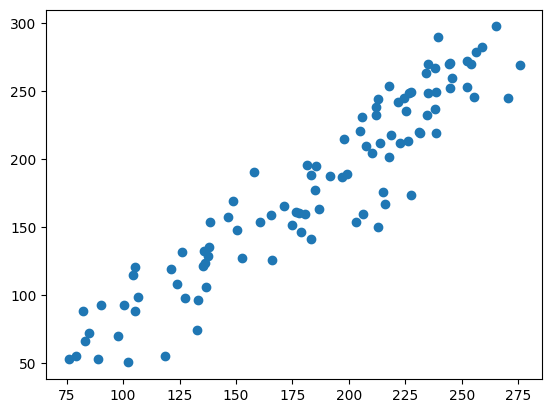

In [61]:
plt.scatter(sales, TV)


In [62]:
df = pd.DataFrame({"TV": TV, "Radio": radio, "Social": social, "SALES": sales})
df


,TV,Radio,Social,SALES
0,213.357414,70.533616,49.127126,226.014301
1,69.741008,56.258580,19.867960,97.874658
2,153.945574,10.692370,18.737651,138.696515
3,263.767315,21.393611,49.389523,234.066639
4,212.117141,64.148470,29.335928,213.957395
...,...,...,...,...
95,211.783352,60.062211,42.062123,222.531612
96,53.228117,43.232353,24.881118,89.009712
97,188.585835,42.517791,26.507544,183.250469
98,119.134040,19.414886,12.869837,121.075388


In [63]:
from sklearn.linear_model import LinearRegression

X = df[['TV']]
y = df[["SALES"]]

#fit 
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [64]:
X_range = np.linspace(df['TV'].min(), df['TV'].max(), 100).reshape(-1, 1)

# X_range

y_pred = model.predict(X_range)
model.coef_
# model.intercept_

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[0.75738304]])

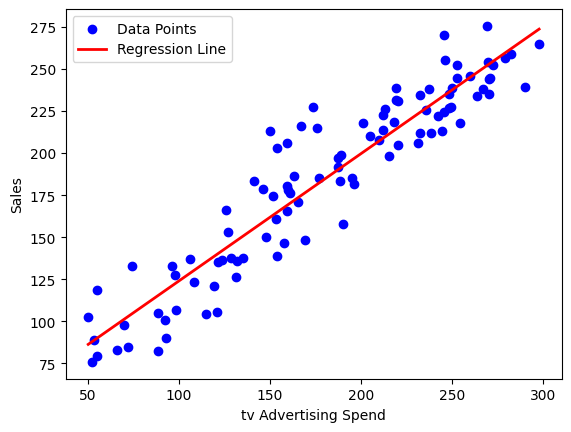

In [65]:
plt.scatter(df['TV'], df['SALES'], color='blue', label='Data Points')
plt.plot(X_range, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('tv Advertising Spend')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [66]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df["SALES"], y_pred)
# mse2 = ((df['SALES'] - y_pred)**2).mean()


mse ** 0.5

79.4480372945888

In [67]:
# # #y = m1x1 + m2x2 + m3x3 + b
# sales = 0.8 * TV + 0.6 * radio + 0.3 * social + 5 + np.random.normal(0, 10, n_samples)

X = df[["TV", "Radio", "Social"]]
Y = df["SALES"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

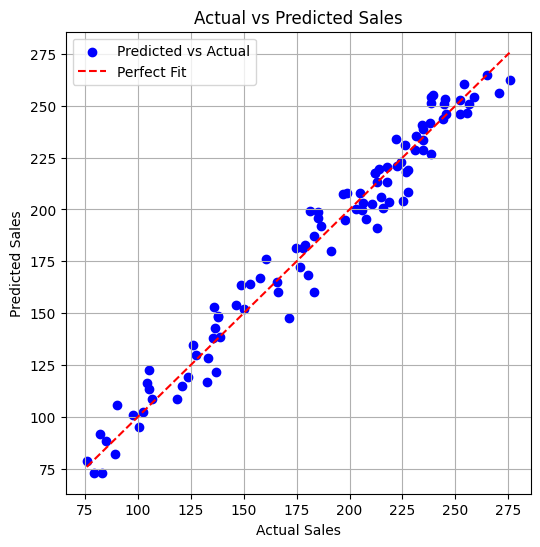

In [68]:
plt.figure(figsize=(6, 6))
plt.scatter(Y, predictions, color='blue', label='Predicted vs Actual')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', label='Perfect Fit')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# # #y = m1x1 + m2x2 + m3x3 + b
# sales = 0.8 * TV + 0.6 * radio + 0.3 * social + 5 + np.random.normal(0, 10, n_samples)
# sales = 0.77 * tv + 0.599 * radio + 0.34 * social + 6.62

print(model.intercept_)
print(model.coef_)


[6.6248685]
[[0.77407818 0.59946086 0.34269577]]


In [76]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df["SALES"], y_pred)
# mse2 = ((df['SALES'] - y_pred)**2).mean()


mse ** 0.5

79.4480372945888

In [77]:
#training and testing

from sklearn.model_selection import train_test_split

#split 80-20

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

model.coef_

array([0.77810841, 0.58824331, 0.32303329])

In [79]:
y_pred = model.predict(X_test)

In [80]:
y_pred

array([152.49045743, 244.5064359 , 238.97300361, 223.34008203,
       116.59646738, 207.33737893, 190.55880421, 208.76692892,
       153.33376645, 230.67920335, 260.82685034, 218.66071397,
       262.54376811, 138.20205495, 217.95806135, 219.5649008 ,
       119.0893112 , 154.10149055, 175.95489816, 213.56805102])

In [82]:
Y_test

83    150.271646
53    244.209517
70    234.529603
45    224.198732
44    132.851812
39    196.928158
22    212.967773
80    204.792021
10    135.821162
0     226.014301
18    253.890681
30    211.988646
73    275.549984
33    135.431202
90    212.137286
4     213.957395
76    123.669104
77    146.273857
12    160.576245
31    217.586645
Name: SALES, dtype: float64

In [84]:
mse = mean_squared_error(y_pred, Y_test)
mse ** 0.5

9.78311056190696

In [85]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, Y, cv = 5, scoring = "r2")
print(scores)
np.mean(scores)

[0.95590507 0.92898103 0.98069459 0.97348452 0.95960148]


0.9597333363459519